# Two-Sigma LVG Toy Curves

This notebook varies only two LVG diffusion coefficients: one on the left of spot and one on the right of spot. It plots the resulting time-value curves for a few selected sigma pairs, including the two-sigma pair that best fits the arbitrage-free time-value curve by least squares.


For each sigma pair, the left and right time-value wings are joined using the same lambda-matching equations as the full LVG construction. This lets us see how changing only two sigmas changes the shape of V(K) and where those pairs sit on the two-sigma J heatmap.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize


In [2]:
S0 = 1271.87
L = 0.0
Kbar = 2000.0


In [3]:
arb = pd.read_csv(
    "ArbFree_calls_strikes.csv",
    header=None,
    names=["C", "K"],
).sort_values("K").reset_index(drop=True)

K_arb = arb["K"].to_numpy(dtype=float)
C_arb = arb["C"].to_numpy(dtype=float)
V_arb = C_arb - np.maximum(S0 - K_arb, 0.0)

quotes = pd.read_csv(
    "Quotes.csv",
    header=None,
    names=["K", "ask", "bid"],
).sort_values("K").reset_index(drop=True)

K_q = quotes["K"].to_numpy(dtype=float)
ask_q = quotes["ask"].to_numpy(dtype=float)
bid_q = quotes["bid"].to_numpy(dtype=float)

intrinsic_q = np.maximum(S0 - K_q, 0.0)
V_bid = bid_q - intrinsic_q
V_ask = ask_q - intrinsic_q


In [4]:
def two_sigma_lambdas(sigma_left, sigma_right):
    # we have these functions from past notebooks
    left_distance_at_spot = (S0 - L) / sigma_left
    right_distance_at_spot = (Kbar - S0) / sigma_right

    v_left = np.exp(left_distance_at_spot) - np.exp(-left_distance_at_spot)
    v_right = np.exp(right_distance_at_spot) - np.exp(-right_distance_at_spot)

    d_left = (
        np.exp(left_distance_at_spot) + np.exp(-left_distance_at_spot)
    ) / sigma_left
    d_right = -(
        np.exp(right_distance_at_spot) + np.exp(-right_distance_at_spot)
    ) / sigma_right

    denominator = d_left * v_right - v_left * d_right
    lambda_left = v_right / denominator
    lambda_right = v_left / denominator
    value_at_spot = lambda_left * v_left

    return lambda_left, lambda_right, value_at_spot


def two_sigma_lvg_V(K_values, sigma_left, sigma_right):
    K_values = np.asarray(K_values, dtype=float)
    V_model = np.empty_like(K_values)

    lambda_left, lambda_right, _ = two_sigma_lambdas(
        sigma_left,
        sigma_right,
    )

    left_mask = K_values <= S0
    right_mask = K_values > S0

    K_left = K_values[left_mask]
    left_distance = (K_left - L) / sigma_left
    V_model[left_mask] = lambda_left * (
        np.exp(left_distance) - np.exp(-left_distance)
    )

    K_right = K_values[right_mask]
    right_distance = (Kbar - K_right) / sigma_right
    V_model[right_mask] = lambda_right * (
        np.exp(right_distance) - np.exp(-right_distance)
    )

    return V_model


def two_sigma_J(sigma_left, sigma_right):
    _, _, value_at_spot = two_sigma_lambdas(sigma_left, sigma_right)
    Cpp_left = value_at_spot / sigma_left**2
    Cpp_right = value_at_spot / sigma_right**2
    jump = Cpp_right - Cpp_left
    return jump**2


In [5]:
def two_sigma_sse(params):
    sigma_left, sigma_right = params

    if sigma_left <= 0.0 or sigma_right <= 0.0:
        return np.inf

    V_model = two_sigma_lvg_V(K_arb, sigma_left, sigma_right)
    if not np.all(np.isfinite(V_model)):
        return np.inf

    return np.sum((V_model - V_arb) ** 2)

fit_result = minimize(
    two_sigma_sse,
    x0=np.array([50.0, 50.0]),
    method="L-BFGS-B",
    bounds=[(10.0, 500.0), (10.0, 500.0)],
)

sigma_left_fit, sigma_right_fit = fit_result.x
print("SSE-fitted sigma_left:", sigma_left_fit)
print("SSE-fitted sigma_right:", sigma_right_fit)
print("J at fitted pair:", two_sigma_J(sigma_left_fit, sigma_right_fit))

sigma_pairs = [
    ("SSE fitted", sigma_left_fit, sigma_right_fit),
    ("(10, 10)", 10.0, 10.0),
    ("(100, 100)", 100.0, 100.0),
    ("(500, 500)", 500.0, 500.0),
]

colors = {
    "SSE fitted": "red",
    "(10, 10)": "tab:orange",
    "(100, 100)": "tab:blue",
    "(500, 500)": "tab:green",
}


SSE-fitted sigma_left: 37.160227169241665
SSE-fitted sigma_right: 28.556488089049186
J at fitted pair: 6.573673797811238e-05


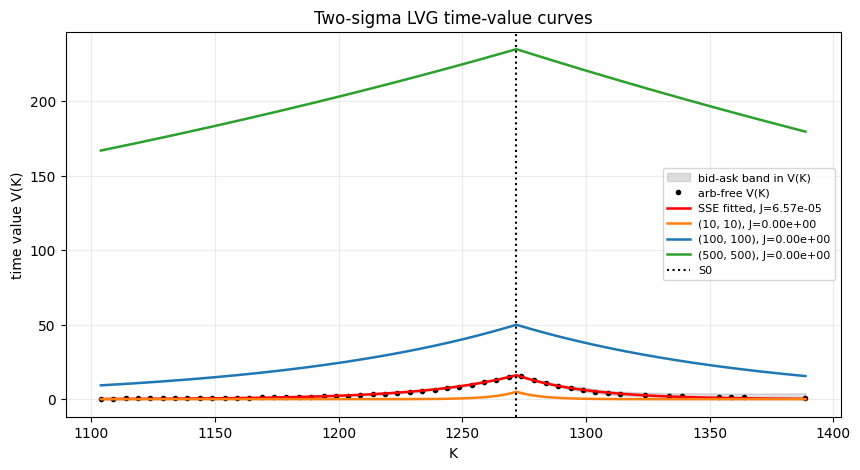

In [6]:
# plot of V(K) for selected sigma pairs.
K_plot = np.linspace(K_q.min(), K_q.max(), 1000)

plt.figure(figsize=(10, 5))
plt.fill_between(
    K_q,
    V_bid,
    V_ask,
    color="gray",
    alpha=0.25,
    label="bid-ask band in V(K)",
)
plt.plot(K_arb, V_arb, "o", color="black", markersize=3, label="arb-free V(K)")

for label, sigma_left, sigma_right in sigma_pairs:
    V_model = two_sigma_lvg_V(K_plot, sigma_left, sigma_right)
    plt.plot(
        K_plot,
        V_model,
        "-",
        linewidth=1.8,
        color=colors[label],
        label=f"{label}, J={two_sigma_J(sigma_left, sigma_right):.2e}",
    )

plt.axvline(S0, color="black", linestyle=":", label="S0")
plt.xlabel("K")
plt.ylabel("time value V(K)")
plt.title("Two-sigma LVG time-value curves")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8)
plt.show()


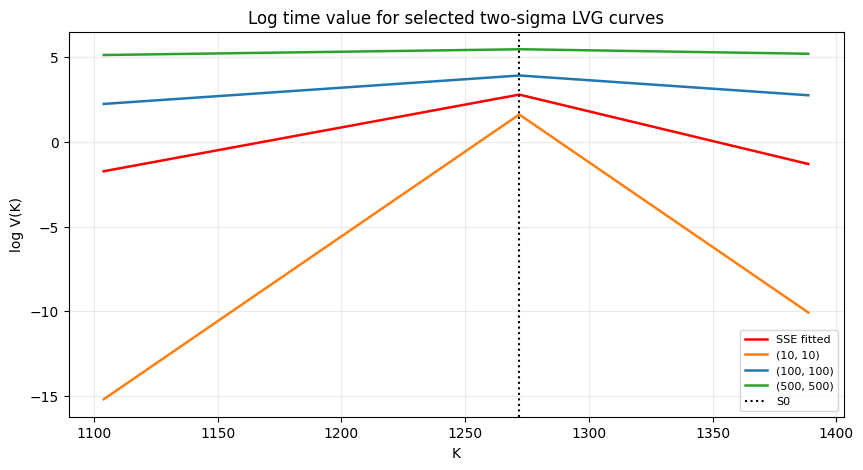

In [7]:
# same comparison on a log scale for clarity in the tails.
plt.figure(figsize=(10, 5))

for label, sigma_left, sigma_right in sigma_pairs:
    V_model = two_sigma_lvg_V(K_plot, sigma_left, sigma_right)
    V_safe = np.maximum(V_model, 1e-12)
    plt.plot(
        K_plot,
        np.log(V_safe),
        "-",
        linewidth=1.8,
        color=colors[label],
        label=label,
    )

plt.axvline(S0, color="black", linestyle=":", label="S0")
plt.xlabel("K")
plt.ylabel("log V(K)")
plt.title("Log time value for selected two-sigma LVG curves")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8)
plt.show()


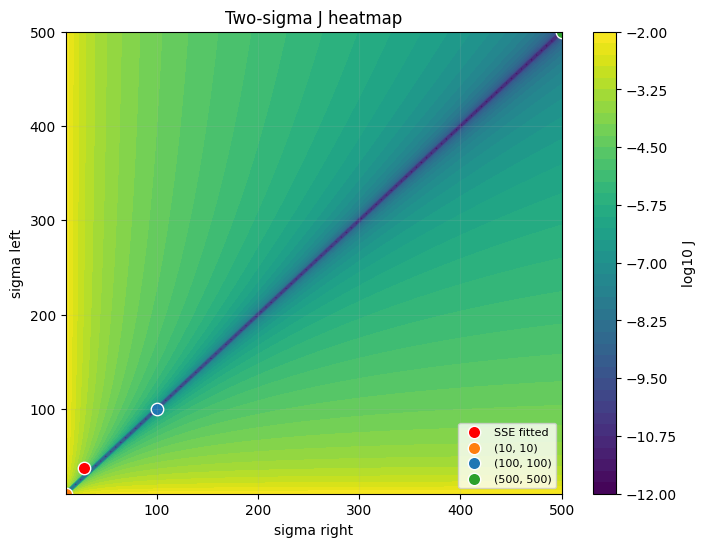

In [8]:
# reproduce the two-sigma J heatmap and mark the selected sigma pairs.
sigma_left_grid = np.linspace(10.0, 500.0, 100)
sigma_right_grid = np.linspace(10.0, 500.0, 100)
J_values = np.zeros((len(sigma_left_grid), len(sigma_right_grid)))

for i, sigma_left in enumerate(sigma_left_grid):
    for j, sigma_right in enumerate(sigma_right_grid):
        J_values[i, j] = two_sigma_J(sigma_left, sigma_right)

X, Y = np.meshgrid(sigma_right_grid, sigma_left_grid)

plt.figure(figsize=(8, 6))
contour = plt.contourf(
    X,
    Y,
    np.log10(np.maximum(J_values, 1e-12)),
    levels=40,
)
plt.colorbar(contour, label="log10 J")

for label, sigma_left, sigma_right in sigma_pairs:
    plt.scatter(
        [sigma_right],
        [sigma_left],
        color=colors[label],
        edgecolor="white",
        s=80,
        label=label,
    )

plt.xlabel("sigma right")
plt.ylabel("sigma left")
plt.title("Two-sigma J heatmap")
plt.grid(True, alpha=0.15)
plt.legend(fontsize=8, loc="lower right")
plt.show()
